In [1]:
from sctoolbox.utils.jupyter import bgcolor, _compare_version

# change the background of input cells
bgcolor("PowderBlue", select=[2, 6, 8, 10, 12, 14])

nb_name = "GSEA.ipynb"

_compare_version(nb_name)

# Gene Set Enrichment Analysis (GSEA)
<hr style="border:2px solid black"> </hr>

## 1 - Description

**Requires an anndata object with precomputed marker genes. Marker genes can be generated with the marker gene notebook (`general_notebooks/group_markers.ipynb`).**

**Move this notebook into the notebook folder (e.g. `rna_analysis/notebooks/`) of the respective analysis before using it!**

The main function of this notebook is to perform enrichment analysis described as "\[...\] a computational method for inferring knowledge about an input gene set by comparing it to annotated gene sets representing prior biological knowledge."\[[source](https://maayanlab.cloud/Enrichr/help#background)\]. So in other words, the goal is to collect enriched GO pathways for clusters of cells (e.g. cell types) based on cluster defining sets of marker genes.  
Available methods in this notebook are [Enrichr](https://maayanlab.cloud/Enrichr/) and [GSEA preank](https://www.genepattern.org/modules/docs/GSEAPreranked/1#gsc.tab=0), which are both implemented in [GSEApy](https://github.com/zqfang/GSEApy).

"enrichr performs a hypergeometric test comparing the set of "significant" genes against the "universe" (or background) genes. GSEA is a Komolgorov-Smirnov test on the whole ranked gene list, testing if some category (e.g., a KEGG pathway) is more abundant at the top of the list than expected by chance." - [source](https://www.biostars.org/p/9468150/)

---

## 2 - Setup

In [2]:
import sctoolbox.utils as utils
import sctoolbox.tools as tools
import sctoolbox.plotting as pl
from sctoolbox import settings

import pandas as pd
import gseapy as gp
import tqdm
import matplotlib.pyplot as plt
import warnings

settings.settings_from_config("config.yaml", key="GSEA")

with pd.option_context("display.max.rows", None, "display.max_colwidth", None):
    display(utils.general.get_version_report(report="versions.yml"))

[WARNING] Log file '../logs/GSEA_log.txt' already exists. The file will be overwritten since 'overwrite_log' is set to True.


,Name,Version
0,Python,"3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0]"
1,sctoolbox,NA
2,pandas,2.3.3
3,gseapy,1.1.11
4,numpy,2.3.5


---

## 3 - General Input

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [3]:
# Set input anndata
last_notebook_adata = "anndata_marker_post_annot.h5ad"

# Define the dataset species!
organism = "zebrafish"

---

## 4 - Load anndata

In [4]:
adata = utils.adata.load_h5ad(last_notebook_adata)

with pd.option_context("display.max.rows", 5, "display.max.columns", None):
    display(adata)
    display(adata.obs)
    display(adata.var)

/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


[INFO] The adata object was loaded from: ../adatas/anndata_marker_post_annot.h5ad


AnnData object with n_obs × n_vars = 6035 × 20718
    obs: 'paper_cluster', 'filename', 'sample', 'timepoint', 'batch', 'Paper cell type', 'total_counts', 'log1p_total_counts', 'total_counts_is_mito', 'log1p_total_counts_is_mito', 'pct_counts_is_mito', 'total_counts_is_ribo', 'log1p_total_counts_is_ribo', 'pct_counts_is_ribo', 'doublet_score', 'predicted_doublet', 'predicted_sex', 'n_genes', 'log1p_n_genes', 'S_score', 'G2M_score', 'phase', 'leiden', 'LISI_score_X_pca', 'LISI_score_X_umap', 'phase_density', 'sample_density', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'leiden_1.6', 'leiden_1.7', 'leiden_1.8', 'leiden_1.9', '1.8_1', '1.8_2', '1.8_3', '1.8_4', '1.8_5', 'clustering', 'MR_symbol_1.8_5', 'SCSA_symbol_1.8_5', 'MR_score_1.8_5', 'SCSA_score_1.8_5', 'MR_ui_1.8_5', 'SCSA_ui_1.8_5'
    var: 'gene_id', 'is_mito', 'is_

,paper_cluster,filename,sample,timepoint,batch,Paper cell type,total_counts,log1p_total_counts,total_counts_is_mito,log1p_total_counts_is_mito,pct_counts_is_mito,total_counts_is_ribo,log1p_total_counts_is_ribo,pct_counts_is_ribo,doublet_score,predicted_doublet,predicted_sex,n_genes,log1p_n_genes,S_score,G2M_score,phase,leiden,LISI_score_X_pca,LISI_score_X_umap,phase_density,sample_density,leiden_0.1,leiden_0.2,leiden_0.3,leiden_0.4,leiden_0.5,leiden_0.6,leiden_0.7,leiden_0.8,leiden_0.9,leiden_1.0,leiden_1.1,leiden_1.2,leiden_1.3,leiden_1.4,leiden_1.5,leiden_1.6,leiden_1.7,leiden_1.8,leiden_1.9,1.8_1,1.8_2,1.8_3,1.8_4,1.8_5,clustering,MR_symbol_1.8_5,SCSA_symbol_1.8_5,MR_score_1.8_5,SCSA_score_1.8_5,MR_ui_1.8_5,SCSA_ui_1.8_5
AAACCTGAGGAGTAGA-1,1,GSM5402441_scRNAseq_Sox10_Cre_bact_BtR_150dpf_...,GSM5402441,150dpf,rep_1,Stroma 1,1419.0,7.258412,15.0,2.772589,1.057082,343.0,5.840641,24.171951,0.056738,False,Male,475,6.165418,-0.047667,-0.067436,G1,0,1.488264,1.596839,0.907842,0.894167,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,Stroma,Stroma,Stroma,Stroma,Stroma,Stroma
AAACCTGAGTACGCGA-1,9,GSM5402441_scRNAseq_Sox10_Cre_bact_BtR_150dpf_...,GSM5402441,150dpf,rep_1,Teeth,1621.0,7.391415,44.0,3.806663,2.714374,505.0,6.226537,31.153610,0.049233,False,Male,540,6.293419,-0.060441,-0.079467,G1,0,1.224180,1.727857,0.906035,0.926660,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,Stroma,Stroma,Stroma,Stroma,Stroma,Stroma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCAACACCA-3,9,GSM5402443_scRNAseq_Sox10_Cre_bact_BtR_150dpf_...,GSM5402443,150dpf,rep_3,Teeth,1300.0,7.170888,85.0,4.454347,6.538462,561.0,6.331502,43.153847,0.059896,False,Male,360,5.888878,-0.007351,-0.015209,G1,0,2.846069,1.898375,0.976483,0.400197,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,16,16,16,17,8,1,1,1,Stroma,Stroma,Stroma,Stroma,Stroma,Stroma
TTTGTCATCCGAACGC-3,6,GSM5402443_scRNAseq_Sox10_Cre_bact_BtR_150dpf_...,GSM5402443,150dpf,rep_3,Gill cartilage,3631.0,8.197538,28.0,3.367296,0.771137,1142.0,7.041412,31.451393,0.074581,False,Male,909,6.813445,-0.061421,0.040508,G2M,12,2.078850,2.291138,0.327639,0.583865,2,2,4,7,8,7,8,9,9,13,10,12,10,10,2,9,11,13,11,13,14,6,18,9,9,Gill cartilage,Gill cartilage,Gill cartilage,Gill cartilage,Gill cartilage,Gill cartilage


,gene_id,is_mito,is_ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm
gene_symbol,,,,,,,,,,,,,
ptpn12,ENSDARG00000102141,False,False,4,0.000663,0.000663,99.933720,4.0,1.609438,False,0.001794,1.176934,1.159880
phtf2,ENSDARG00000102123,False,False,1,0.000166,0.000166,99.983430,1.0,0.693147,False,0.000034,-1.577754,-3.168473
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TagBFP,TagBFP,False,False,44,0.033637,0.033084,99.270920,203.0,5.318120,True,0.016864,1.362143,1.450892
DsRedExpress,DsRedExpress,False,False,4491,4.669925,1.735176,25.584093,28183.0,10.246510,False,1.337943,1.343475,-0.360641


---

## 5 - Select library

**Molecular Function**  
Molecular-level activities performed by gene products. Molecular function terms describe activities that occur at the molecular level, such as “catalysis” or “transport”. GO molecular function terms represent activities rather than the entities (molecules or complexes) that perform the actions, and do not specify where, when, or in what context the action takes place. Molecular functions generally correspond to activities that can be performed by individual gene products (i.e. a protein or RNA), but some activities are performed by molecular complexes composed of multiple gene products. Examples of broad functional terms are catalytic activity and transporter activity; examples of narrower functional terms are adenylate cyclase activity or Toll-like receptor binding. To avoid confusion between gene product names and their molecular functions, GO molecular functions are often appended with the word “activity” (a protein kinase would have the GO molecular function protein kinase activity).  

**Cellular Component**  
A location, relative to cellular compartments and structures, occupied by a macromolecular machine. There are two ways in which the gene ontology describes locations of gene products: (1) the cellular anatomical entities, in which a gene product carries out a molecular function. Cellular anatomical entities includes cellular structures such as the plasma membrane and the cytoskeleton, as well as membrane-enclosed cellular compartments such as the mitochondrion, and (2) the stable macromolecular complexes of which they are parts, e.g., the clathrin complex.  

**Biological Process**  
The larger processes, or ‘biological programs’ accomplished by multiple molecular activities. Examples of broad biological process terms are DNA repair or signal transduction. Examples of more specific terms are pyrimidine nucleobase biosynthetic process or glucose transmembrane transport. Note that a biological process is not equivalent to a pathway. At present, the GO does not try to represent the dynamics or dependencies that would be required to fully describe a pathway.

-- https://geneontology.org/docs/ontology-documentation/

**List of available librarys**

In [5]:
[db for db in gp.get_library_name(organism) if db.startswith("GO")]

['GO_Biological_Process_2018',
 'GO_Biological_Process_AutoRIF',
 'GO_Biological_Process_AutoRIF_Predicted_Z-score',
 'GO_Biological_Process_GeneRIF',
 'GO_Biological_Process_GeneRIF_Predicted_Z-score',
 'GO_Cellular_Component_2018',
 'GO_Cellular_Component_AutoRIF',
 'GO_Cellular_Component_AutoRIF_Predicted_Z-score',
 'GO_Cellular_Component_GeneRIF',
 'GO_Cellular_Component_GeneRIF_Predicted_Z-score',
 'GO_Molecular_Function_2018',
 'GO_Molecular_Function_AutoRIF',
 'GO_Molecular_Function_AutoRIF_Predicted_Z-score',
 'GO_Molecular_Function_GeneRIF',
 'GO_Molecular_Function_GeneRIF_Predicted_Z-score']

**List of available `marker_keys`**

In [6]:
[k for k in adata.uns.keys() if k.startswith("rank_")]

['rank_feature_1.8_1',
 'rank_feature_1.8_1_filtered',
 'rank_feature_1.8_2',
 'rank_feature_1.8_2_filtered',
 'rank_feature_1.8_3',
 'rank_feature_1.8_3_filtered',
 'rank_feature_1.8_4',
 'rank_feature_1.8_4_filtered',
 'rank_feature_1.8_5',
 'rank_feature_1.8_5_filtered',
 'rank_feature_MR_score_1.8_5',
 'rank_feature_MR_score_1.8_5_filtered',
 'rank_feature_Paper cell type',
 'rank_feature_Paper cell type_filtered',
 'rank_feature_leiden_1.8',
 'rank_feature_leiden_1.8_filtered',
 'rank_genes_groups_1.8_5']

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [7]:
# key for marker table in adata.uns
clustering = "MR_score_1.8_5"  # The marker_key is usually formatted as rank_genes_<clustering>.
marker_key = "rank_feature_MR_score_1.8_5"  # The marker_key under which the ranked gene list is stored in adata.uns

# Select method. Available options: 'prerank', 'enrichr'
method = "prerank"

# Choose public library to use
library_name = "GO_Biological_Process_2018"

# If custom gene sets and background should be used set here.
# The public library will be ignored if custom_gene_set is given.
custom_gene_set = None  # {"Pathway 1": ["Gene1", "Gene2",...], ...}

# enrichr specific parameters
# To use a custom background for the public gene set library only set custom_background.
custom_background = None  # ["Gene 1", "Gene 2", ....]

# prerank specific parameters
threads = 4  # Number of threadsused by prerank function
min_size = 1  # Minimum allowed number of genes from gene set also the data set.
max_size = 1000  # Maximum allowed number of genes from gene set also the data set.
permutation_num = 1000  # Number of permutations.
seed = 0  # Seed for prerank run

overwrite = False

---

## 6 - Run gene set enrichment analysis

The results will be stored in the anndata object (`adata.uns['sctoolbox']['gsea']['enrichment_table']`).

In [8]:
tools.gsea.gene_set_enrichment(adata,
                               method=method,
                               marker_key=marker_key,
                               organism=organism,
                               gene_sets=custom_gene_set,
                               background=custom_background,
                               library_name=library_name,
                               seed=seed,
                               min_size=min_size,
                               max_size=max_size,
                               permutation_num=permutation_num,
                               threads=threads,
                               inplace=True,
                               overwrite=overwrite)

[INFO] Getting gene rank tables.
[INFO] Downloading gene set library.
[INFO] Running prerank for cluster Cycling cells (1/13).
[INFO] Running prerank for cluster Dermal fibroblast (2/13).
[INFO] Running prerank for cluster Epithelia (3/13).
[INFO] Running prerank for cluster Gill cartilage (4/13).
[INFO] Running prerank for cluster Gill progenitor (5/13).
[INFO] Running prerank for cluster Glia (6/13).
[INFO] Running prerank for cluster Periosteum/tendon/ligament (7/13).
[INFO] Running prerank for cluster Perivascular (8/13).
[INFO] Running prerank for cluster Pillar (9/13).
[INFO] Running prerank for cluster Smooth muscle (10/13).
[INFO] Running prerank for cluster Stroma (11/13).
[INFO] Running prerank for cluster Teeth (12/13).
[INFO] Running prerank for cluster Tunica media (13/13).
[INFO] Saving results in 'adata.uns['sctoolbox']['gsea']['enrichment_table']'


---

## 7 - Plotting
<hr style="border:2px solid black"> </hr>

### 7.1 - Dotplot

The dotplot shows the top enriched pathways per cluster. The size of the dot indicates the fraction of genes in the cluster that match the pathway and the color of the dot indicates statistical significance (higher is better).

#### 7.1.1 Combined plot

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [9]:
# Dotplot
figsize = (18, 10)  # Set figure size for dotplot
top_term = 5  # Number of top pathways
sizes = (50, 200)  # Min, max size for dots
x_label_rotation = 45  # Set rotation angle for x-tick labels
cutoff = 0.05  # Terms with `column` value < cut-off are shown.
title = f"Top {top_term} upregulated pathways per cluster"
title_size = 16

---

[INFO] Filtering enrichment table...
[INFO] Generating dotplot...


/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/sctoolbox/plotting/gsea.py:573: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  term_table = term_table.groupby(cluster_col).apply(


[INFO] Saving figure to ../figures/GSEA/GSEA_top-5_per_cluster.pdf


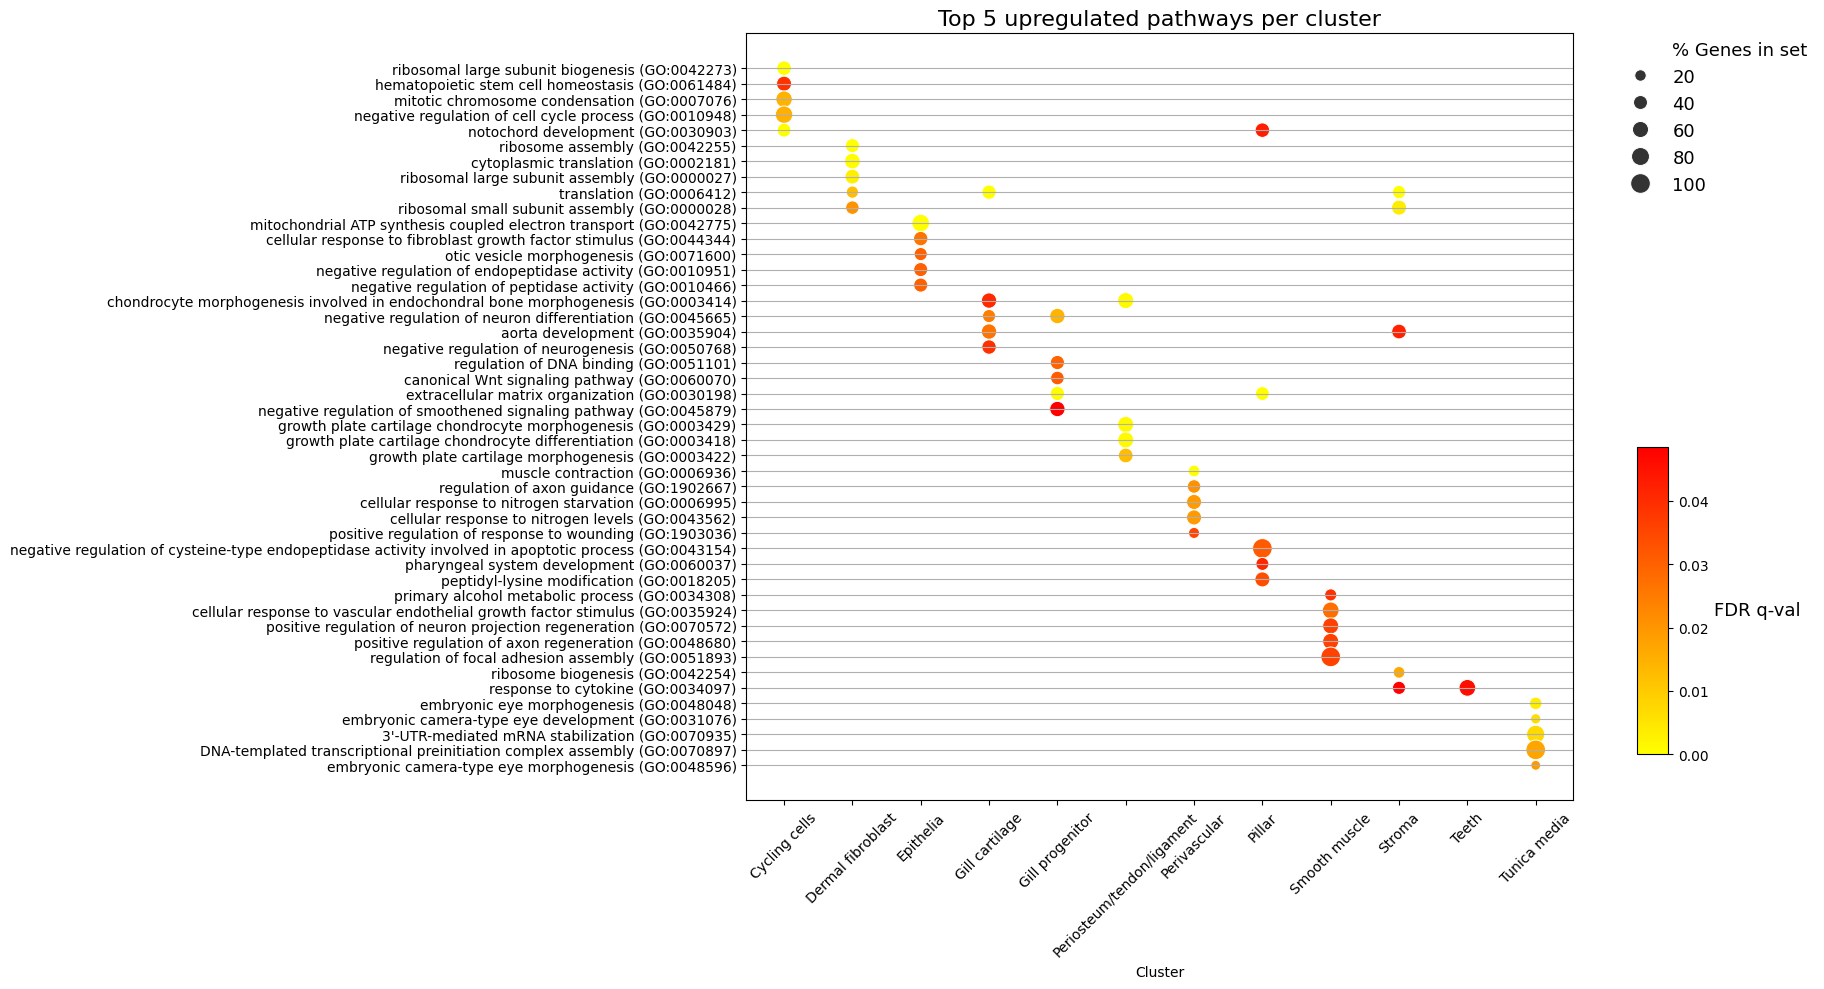

In [10]:
ax = pl.gsea.gsea_dot(adata,
                      cutoff=cutoff,
                      cmap="autumn_r",
                      top_term=top_term,
                      figsize=figsize,
                      sizes=sizes,
                      title=title,
                      title_size=title_size,
                      x_label_rotation=x_label_rotation,
                      x="Cluster",
                      save=f"GSEA_top-{top_term}_per_cluster.pdf",
                      report=f"01_GSEA_top-{top_term}_per_cluster.png")

#### 7.1.2 Dotplot per cluster

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [11]:
# Dotplot
figsize_clust_dot = (10, 5)  # Set figure size for dotplot
top_up = 5  # Number of upregulated pathways to be plotted
top_down = 5  # Number of downregulated pathways to be plotted
size_clust_dot = (50, 200)  # Min, max size for dots
cutoff_clust_dot = 0.05  # Terms with `column` value < cut-off are shown.

---

[INFO] Plotting dotplot for cluster Cycling cells
[INFO] Filtering enrichment table...
[INFO] Generating dotplot...
[INFO] Plotting dotplot for cluster Dermal fibroblast
[INFO] Filtering enrichment table...
[INFO] Generating dotplot...
[INFO] Plotting dotplot for cluster Epithelia
[INFO] Filtering enrichment table...
[INFO] Generating dotplot...
[INFO] Plotting dotplot for cluster Gill cartilage
[INFO] Filtering enrichment table...
[INFO] Generating dotplot...
[INFO] Plotting dotplot for cluster Gill progenitor
[INFO] Filtering enrichment table...
[INFO] Generating dotplot...
[INFO] Plotting dotplot for cluster Glia
[INFO] No enrichted pathways of cluster Glia found with cutoff set to 0.05
[INFO] Plotting dotplot for cluster Periosteum/tendon/ligament
[INFO] Filtering enrichment table...
[INFO] Generating dotplot...
[INFO] Plotting dotplot for cluster Perivascular
[INFO] Filtering enrichment table...
[INFO] Generating dotplot...
[INFO] Plotting dotplot for cluster Pillar
[INFO] Filteri

{'Cycling cells': <Axes: title={'center': 'Top regulated pathways of cluster Cycling cells'}, xlabel='NES'>,
 'Dermal fibroblast': <Axes: title={'center': 'Top regulated pathways of cluster Dermal fibroblast'}, xlabel='NES'>,
 'Epithelia': <Axes: title={'center': 'Top regulated pathways of cluster Epithelia'}, xlabel='NES'>,
 'Gill cartilage': <Axes: title={'center': 'Top regulated pathways of cluster Gill cartilage'}, xlabel='NES'>,
 'Gill progenitor': <Axes: title={'center': 'Top regulated pathways of cluster Gill progenitor'}, xlabel='NES'>,
 'Periosteum/tendon/ligament': <Axes: title={'center': 'Top regulated pathways of cluster Periosteum/tendon/ligament'}, xlabel='NES'>,
 'Perivascular': <Axes: title={'center': 'Top regulated pathways of cluster Perivascular'}, xlabel='NES'>,
 'Pillar': <Axes: title={'center': 'Top regulated pathways of cluster Pillar'}, xlabel='NES'>,
 'Smooth muscle': <Axes: title={'center': 'Top regulated pathways of cluster Smooth muscle'}, xlabel='NES'>,
 'S

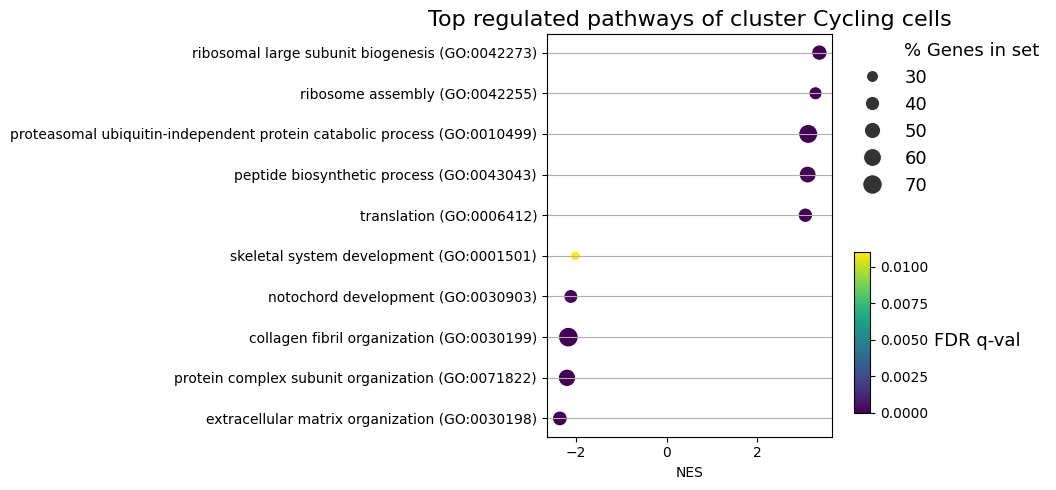

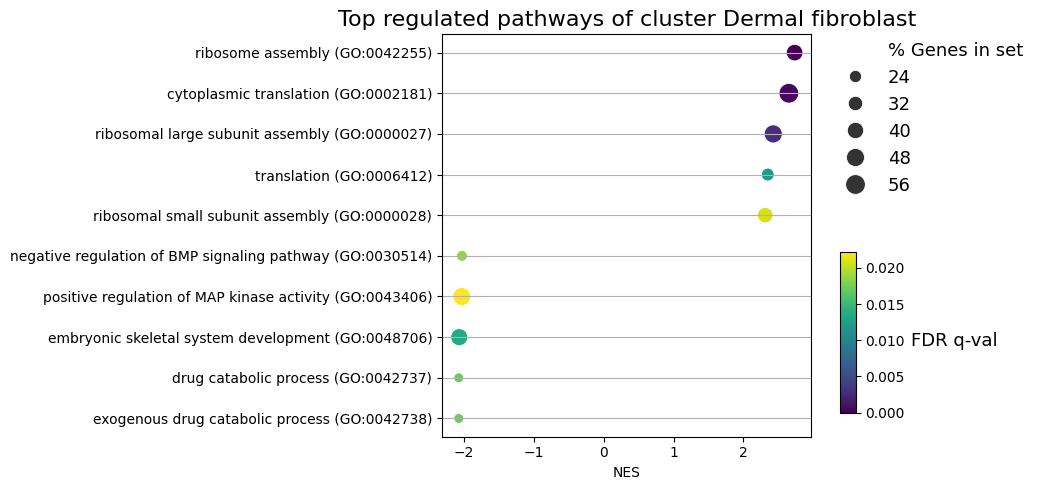

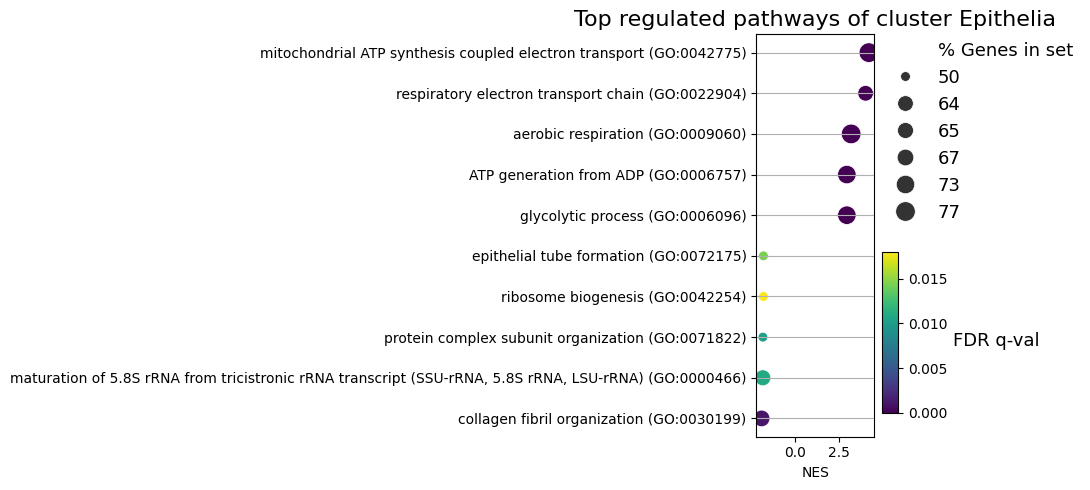

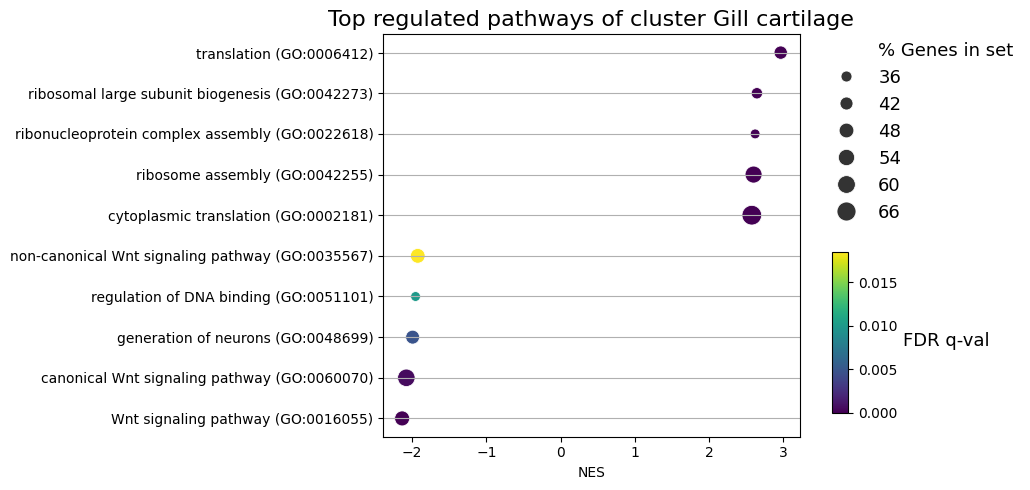

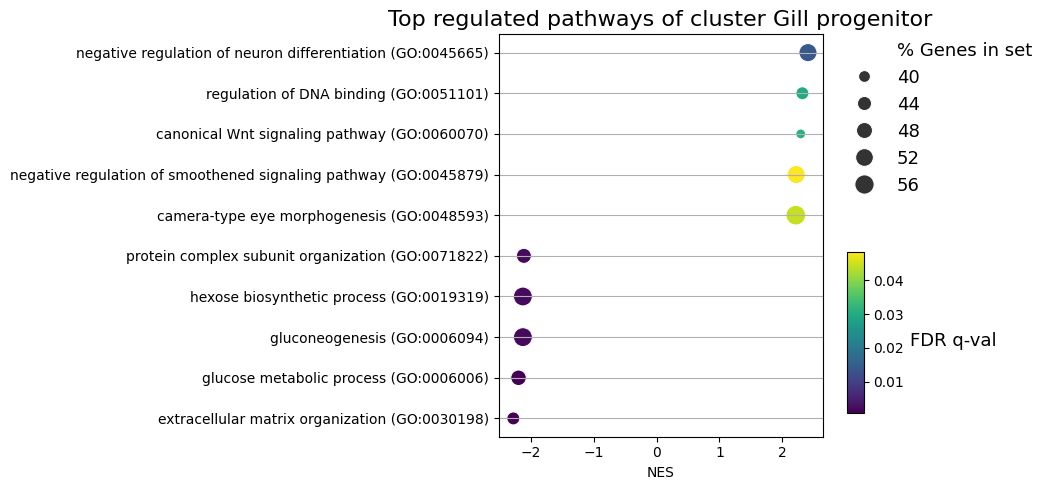

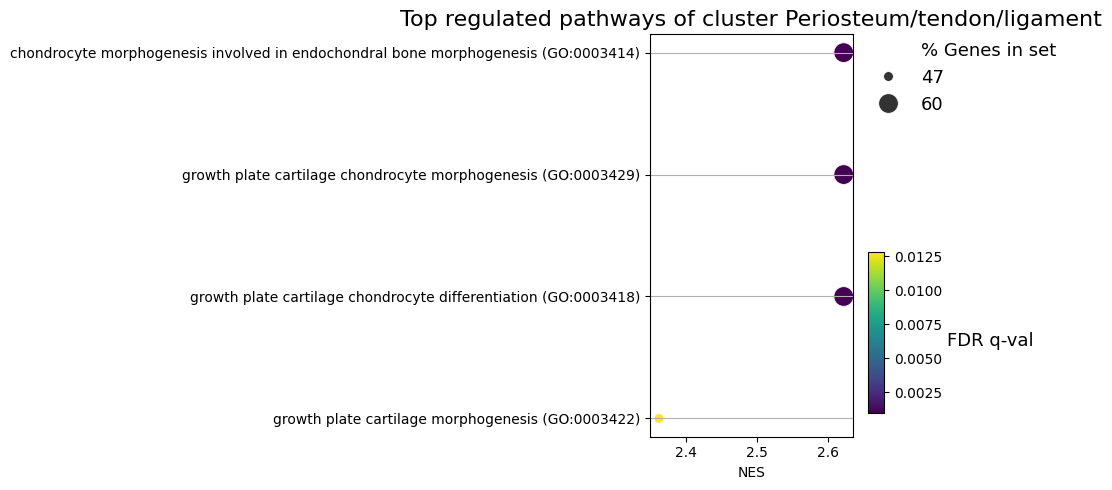

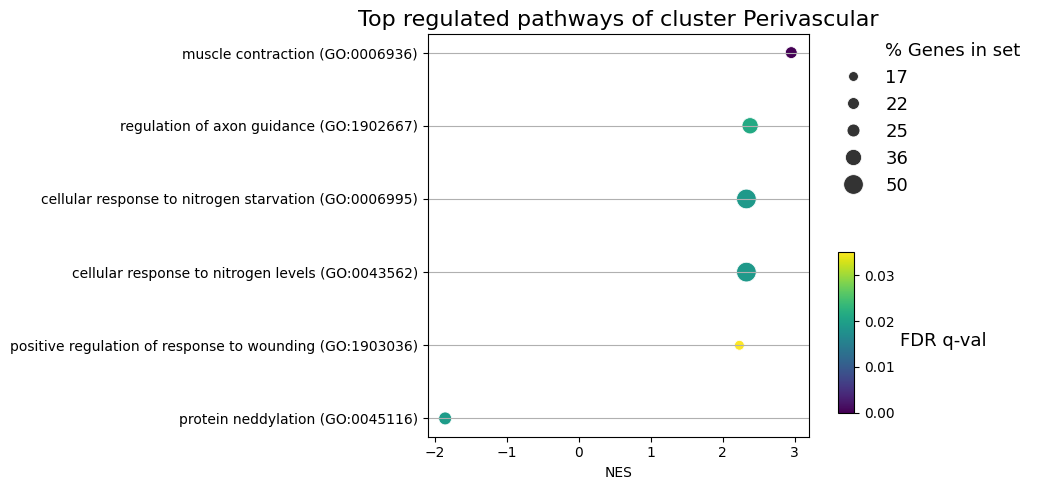

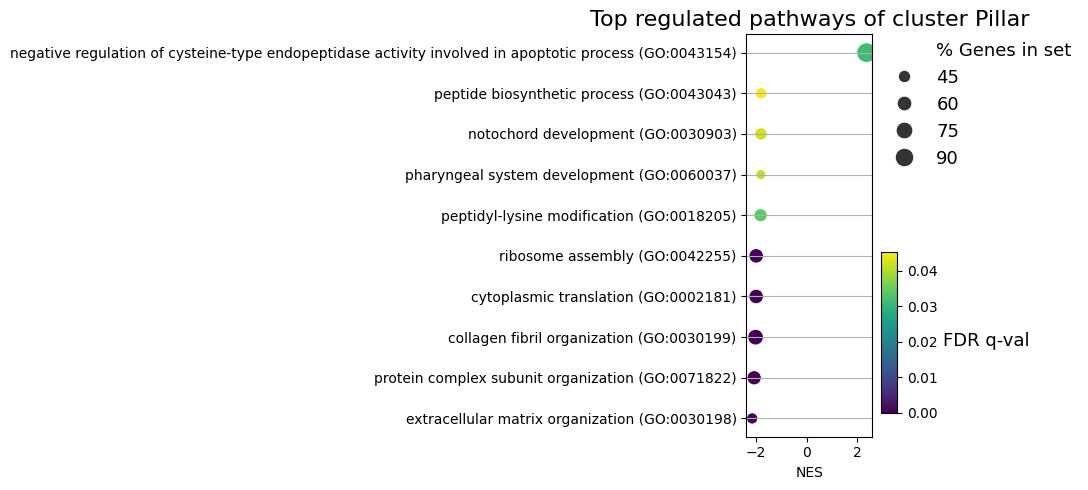

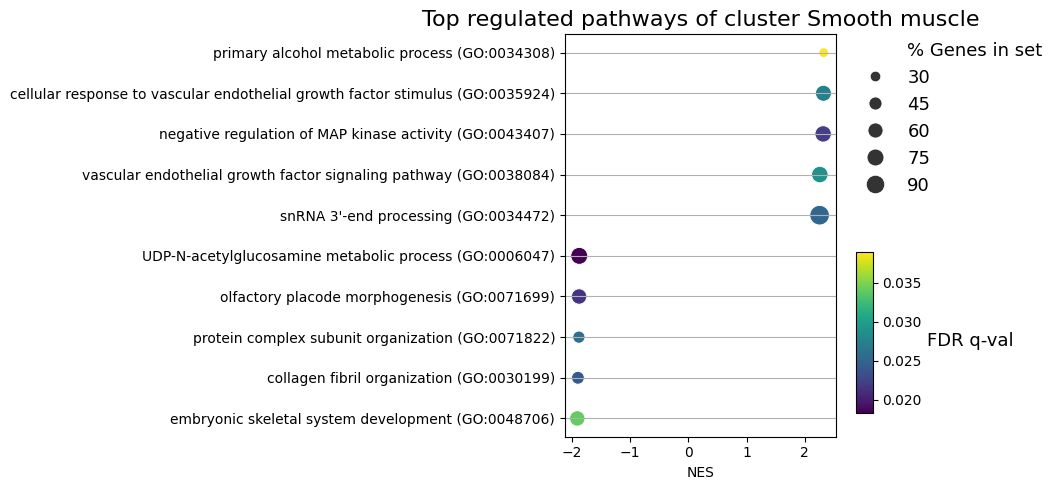

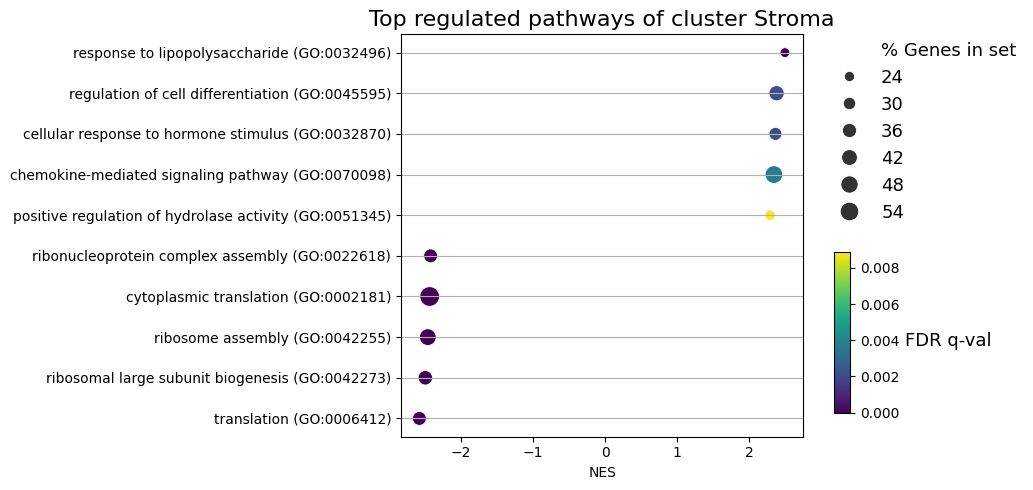

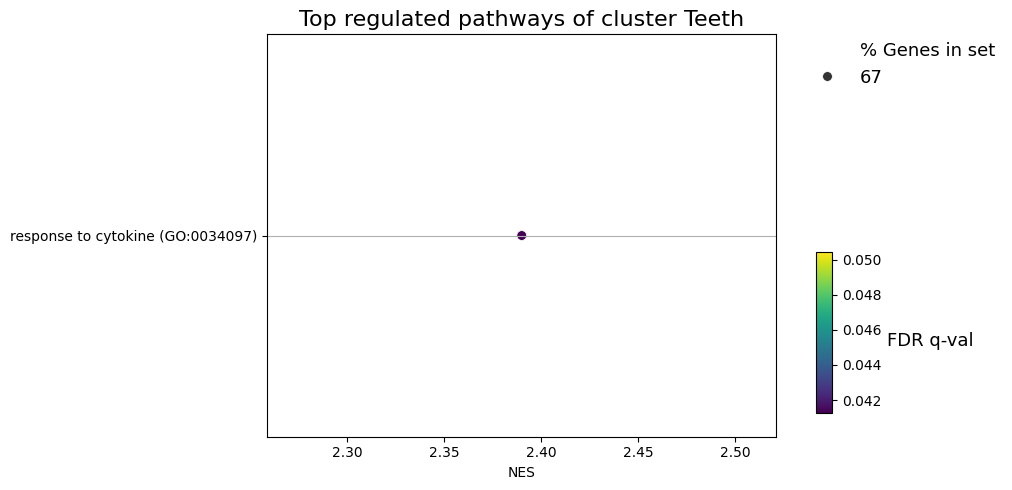

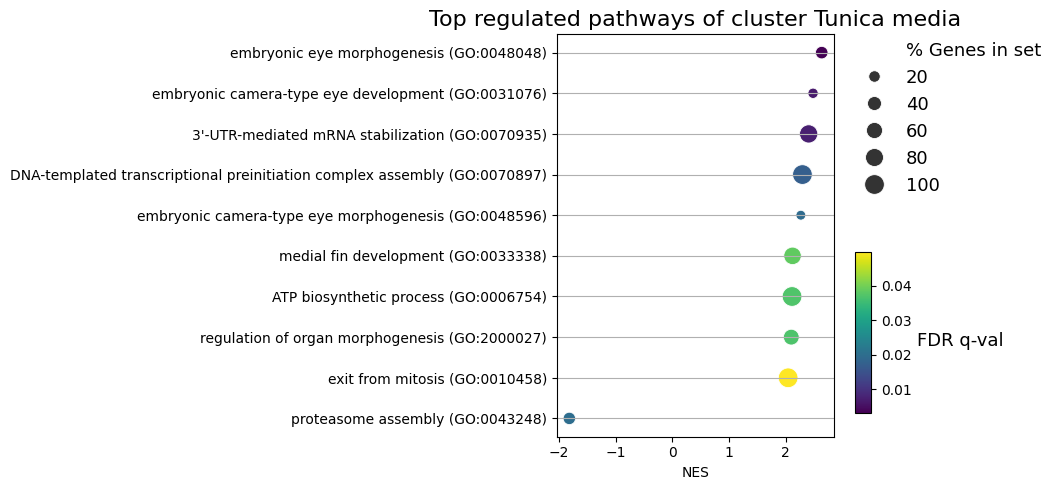

In [12]:
pl.gsea.cluster_dotplot(adata,
                        figsize=figsize_clust_dot,
                        top_up=top_up,
                        top_down=top_down,
                        sizes=size_clust_dot,
                        cutoff=cutoff_clust_dot,
                        save_figs=False)

---

### 7.2 - Term dotplot
The term dotplot focuses on a single term/pathway and thus shows individual genes instead of pathways on the y-axis. A Z-Score is applied to the mean gene expression per cluster to highlight differences in expression between the clusters (x-axis). A pathway of interest can be selected using the plot above.

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [13]:
# Term dotplot
term = "L-phenylalanine catabolic process (GO:0006559)"  # The GO term of interest.
groups = None  # Only show selected groups on x-axis e.g. ["a", "b"]. None to show all.
figsize_term_dot = None # Set figure size for term dotplot e.g. (10, 5).
save_term_dot = f"term_dotplot_{term}_{clustering}.pdf"

# Data layer (advanced)
# decide which processing state of the data should be used for computation
# available layers can be seen above, e.g. "norm" to use normalized data
# it is recommended to use raw or normalized data for statistical testing
layer = "norm"

---

[INFO] Get enrichment table.
[INFO] Get term related genes.
[INFO] Subset AnnData object.
[INFO] Calculate Z scores.
[INFO] Saving figure to ../figures/GSEA/term_dotplot_L-phenylalanine catabolic process (GO:0006559)_MR_score_1.8_5.pdf


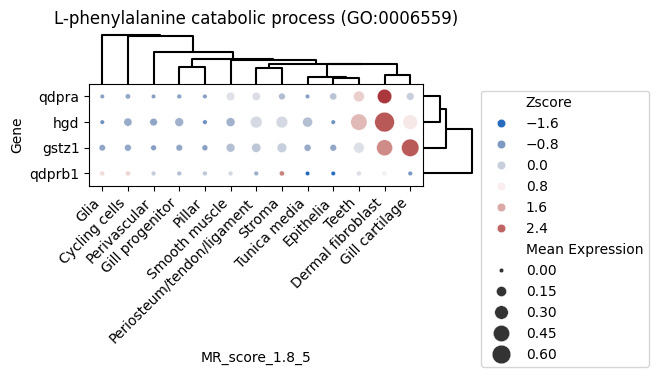

In [14]:
if term:
    pl.gsea.term_dotplot(term=term,
                         adata=adata,
                         groupby=clustering,
                         gene_col="Lead_genes" if method == "prerank" else "Genes",
                         groups=groups,
                         figsize=figsize_term_dot,
                         save=save_term_dot,
                         layer=layer,
                         report='02_' + save_term_dot.replace('pdf', 'png'))

### 7.3 Network plot
The network plot shows connections between enriched pathways per cluster. In the plot the node size corresponds to the percentage of gene overlap in a certain term of interest. The colour of the node corresponds to the significance of the enriched terms and the edge size corresponds to the number of genes that overlap between two connected nodes.

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [15]:
# Significance cutoff for (sig_column), e.g. "FDR q-val"
# All terms with a sig_column value > cutoff are filtered.
cutoff = 0.05 

scale = 1  # Scale factor for node positions
figsize_network = None # Set figure size for term dotplot e.g. (10, 5). Set to None to use default.
ncols = 3  # Number of columns for network plots
save_network = f"pathway_network.pdf"

---

[INFO] Calculate enrichment map...
[INFO] Plotting network...
[INFO] Saving figure to ../figures/GSEA/pathway_network.pdf


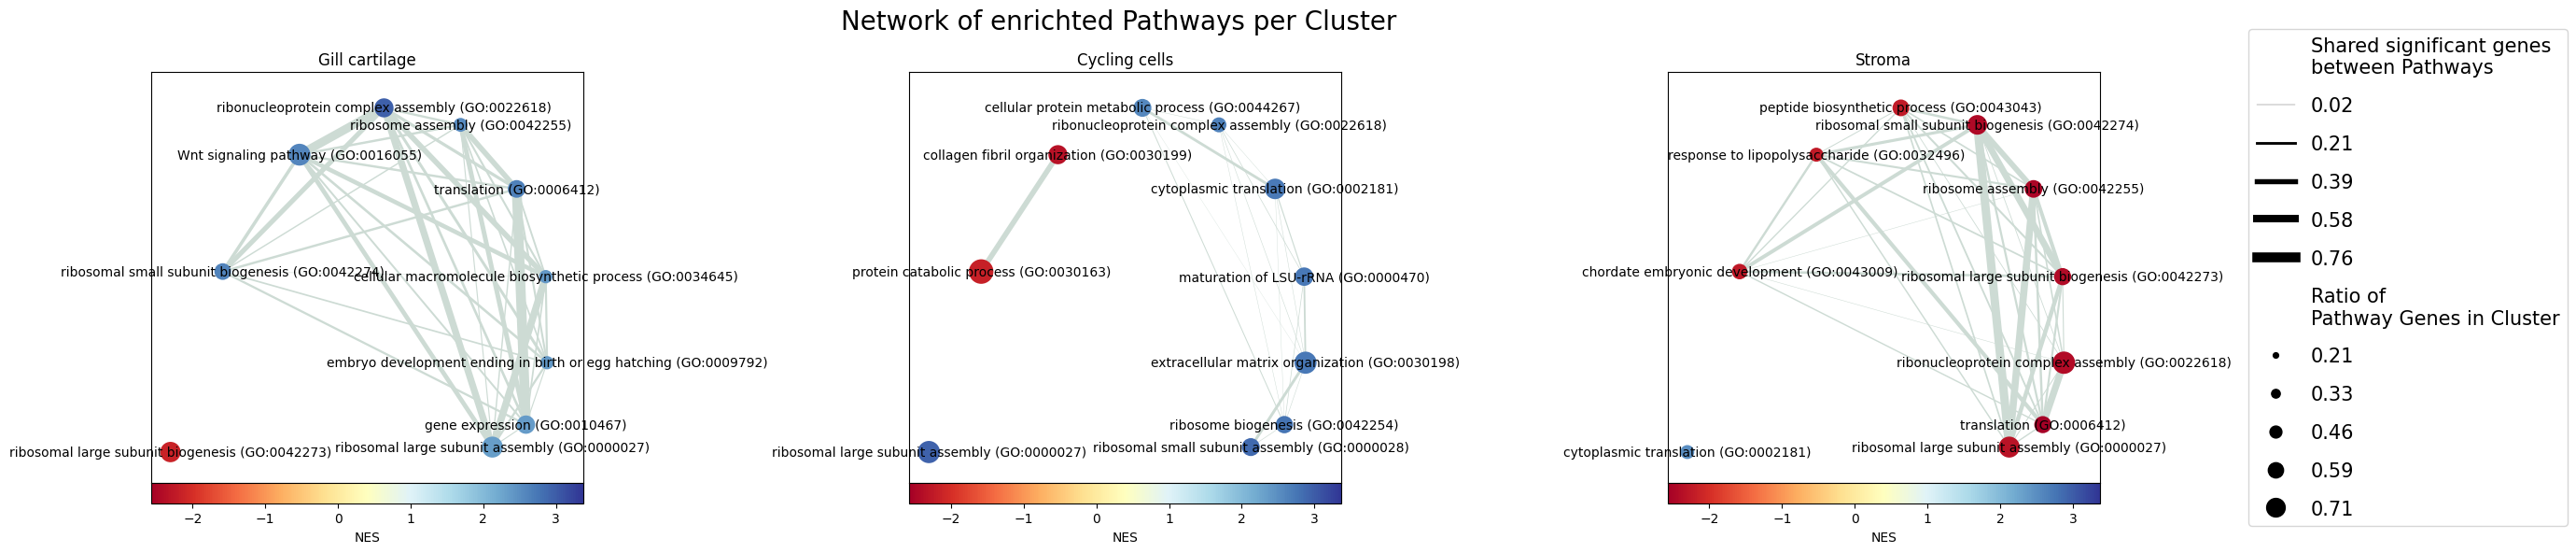

In [16]:
pl.gsea.gsea_network(adata,
                     cutoff=cutoff,
                     scale=scale,
                     figsize=figsize_network,
                     ncols=ncols,
                     save=save_network,
                     report='03_' + save_network.replace('pdf', 'png'))

## 8 - Save adata

In [17]:
utils.io.update_yaml({"GSEA": True}, "method.yml", path_prefix="report")
utils.adata.save_h5ad(adata, "anndata_gsea.h5ad")

[INFO] The adata object was saved to: ../adatas/anndata_gsea.h5ad
